# Тестирование алгоритма сбора графа из файла Geopackage

In [78]:
import osmnx as ox
from osmnx import settings, utils
import networkx as nx
import geopandas as gpd

print('OSMNX:', ox.__version__)

OSMNX: 1.9.4


Загрузка тестового графа

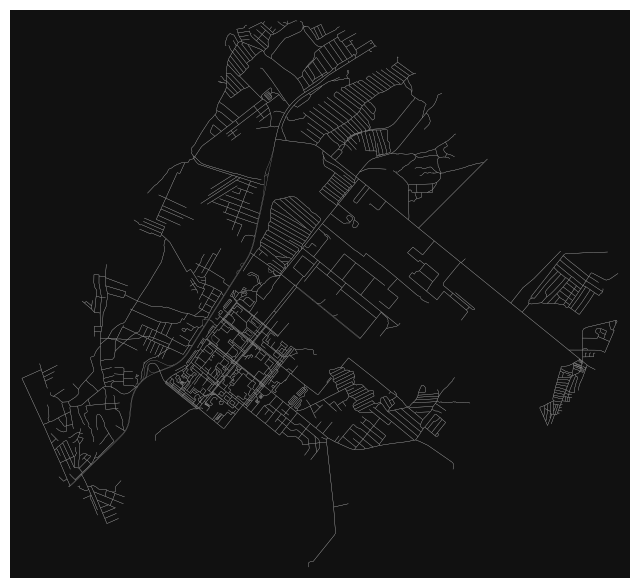

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [79]:
G = ox.load_graphml(r'tests\data\test_rng.ml')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2)

In [80]:
print(G.number_of_nodes(), G.number_of_edges())

5514 12199


Сохранение графа как geopackage

In [81]:
edges_G = ox.graph_to_gdfs(G, nodes=False)
edges_G.head(3)

osmid  oneway lanes      ref    highway  \
u         v          key                                                
290700344 290700348  0    111848408   False     2  04Н-374  secondary   
          2034402448 0    111848408   False     2  04Н-374  secondary   
290700348 290700352  0    111848408   False     2  04Н-374  secondary   

                         maxspeed  reversed   length  travel_time name bridge  \
u         v          key                                                        
290700344 290700348  0         90     False   58.794     0.100790  NaN    NaN   
          2034402448 0         90      True  138.873     0.238068  NaN    NaN   
290700348 290700352  0         90     False  121.847     0.208881  NaN    NaN   

                         service access tunnel  \
u         v          key                         
290700344 290700348  0       NaN    NaN    NaN   
          2034402448 0       NaN    NaN    NaN   
290700348 290700352  0       NaN    NaN    NaN   

                                                                   geometry  
u         v          key                                                     
290700344 290700348  0    LINESTRING (93.36039 56.16267, 93.35966 56.16233)  
          2034402448 0    LINESTRING (93.36039 56.16267, 93.36229 56.16333)  
290700348 290700352  0    LINESTRING (93.35966 56.16233, 93.35819 56.16160)

In [82]:
edges_G.to_file('tmp.gpkg', driver='GPKG')

# Восстановление графа

In [83]:
roads = gpd.read_file('tmp.gpkg')
roads.head(3)

,u,v,key,osmid,oneway,lanes,ref,highway,maxspeed,reversed,length,travel_time,name,bridge,service,access,tunnel,geometry
0,290700344,290700348,0,111848408,False,2,04Н-374,secondary,90,False,58.794,0.100790,NaN,NaN,NaN,NaN,NaN,"LINESTRING (93.36039 56.16267, 93.35966 56.16233)"
1,290700344,2034402448,0,111848408,False,2,04Н-374,secondary,90,True,138.873,0.238068,NaN,NaN,NaN,NaN,NaN,"LINESTRING (93.36039 56.16267, 93.36229 56.16333)"
2,290700348,290700352,0,111848408,False,2,04Н-374,secondary,90,False,121.847,0.208881,NaN,NaN,NaN,NaN,NaN,"LINESTRING (93.35966 56.16233, 93.35819 56.16160)"


In [ ]:
def graph_rise_from_gpkg(roads: gpd.GeoDataFrame,
                         columns_list: list = ['name', 'highway', 'oneway', 'lanes', 'reversed']):

    # Запомним исходную СК
    crs = roads.crs
    
    # Спроектируем DataFrame в местную метрическую систему координат
    try:
        roads_p = ox.project_gdf(roads)
    except:
        pass

    # Создаем пустой граф
    metadata = {
            "created_date": utils.ts(),
            "created_with": f"OSMnx {ox.__version__}",
            # "crs": settings.default_crs,
            "crs": roads_p.crs
        }
    G = nx.MultiDiGraph(**metadata)

    nodes_dict = {}
    node_id = 0

    # Словарь имеющихся ребер (для учета повторов)
    existed_edges_dict = {}

    # Перебираем все строки с записями фрагментов дорог
    for _, road in roads_p.iterrows():
        geometry = road['geometry']

        Warning('Необходимо добавить проверку наличия соответствующих колонок')
        road_data = road[columns_list]
        road_data = {k:v[0] if isinstance(v, list) else v for k,v in road_data.items()}

        # Координаты всех точек в линии
        coords = list(geometry.coords)

        # Добавляем узлы в граф
        for coord in coords:
            if not coord in nodes_dict:
                nodes_dict[coord] = node_id
                node_id += 1

            G.add_node(nodes_dict[coord], x = coord[0], y = coord[1])

        # Добавляем ребра в граф
        for coord1, coord2 in zip(coords[:-1], coords[1:]):
            # Важно! Здесь сейчас длина просто берется из данных указанных в участке дороги на карте. НО должна вычисляться!
            length = ox.distance.euclidean(y1 = coord1[1], x1 = coord1[0],
                                        y2 = coord2[1], x2 = coord2[0])


            # Добавляем ребра в обе стороны
            if road['oneway'] == False:
                # Получаем ключ ребра
                key = existed_edges_dict.get((nodes_dict[coord2], nodes_dict[coord1]), 0)
                # Добавляем ребро
                G.add_edge(nodes_dict[coord2], nodes_dict[coord1], key,
                        #    highway=road['highway'], oneway=road['oneway'],
                           **road_data,
                           length=length)
                # Указываем количество имеющихся ребер
                existed_edges_dict[(nodes_dict[coord2], nodes_dict[coord1])] = key + 1
            else:
                # Добавляем ребро в обратную сторону и в прямую
                if road['reversed']:
                    # Получаем ключ ребра
                    key = existed_edges_dict.get((nodes_dict[coord2], nodes_dict[coord1]), 0)
                    # Добавляем ребро
                    G.add_edge(nodes_dict[coord2], nodes_dict[coord1], key,
                               # highway=road['highway'], oneway=road['oneway'],
                               **road_data,
                               length=length)
                    # Указываем количество имеющихся ребер
                    existed_edges_dict[(nodes_dict[coord2], nodes_dict[coord1])] = key + 1
                else:
                    # Получаем ключ ребра
                    key = existed_edges_dict.get((nodes_dict[coord1], nodes_dict[coord2]), 0)
                    # Добавляем ребро
                    G.add_edge(nodes_dict[coord1], nodes_dict[coord2], key,
                               # highway=road['highway'], oneway=road['oneway'],
                               **road_data,
                               length=length)
                    # Указываем количество имеющихся ребер
                    existed_edges_dict[(nodes_dict[coord1], nodes_dict[coord2])] = key + 1
    
    # перепроецируем граф к исходной системе координат
    G = ox.project_graph(G, to_crs=crs)

    return G

GR = graph_rise_from_gpkg(roads)
print(GR.number_of_nodes(), GR.number_of_edges())

5511 12199


# Тесты

Исходный граф

49


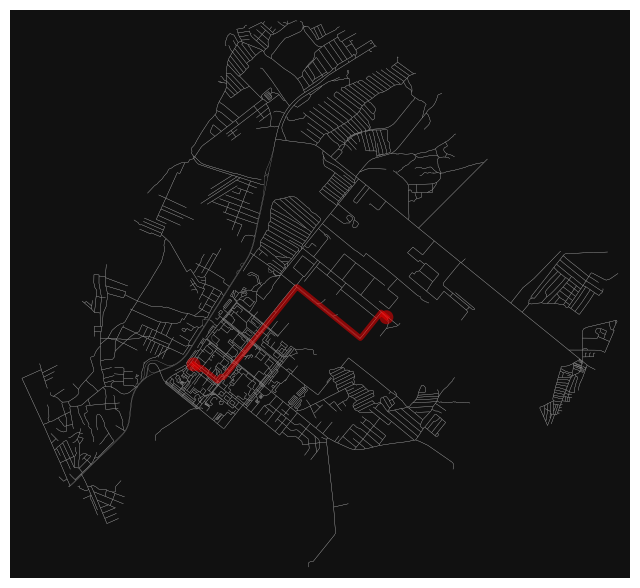

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [110]:
# Получение id узлов, ближайших к координатам
start = ox.distance.nearest_nodes(G, 93.37633, 56.12736, return_dist=False)
finish = ox.distance.nearest_nodes(G, 93.32469, 56.11990, return_dist=False)

# Расчет маршрута
route_G = ox.routing.shortest_path(G, start, finish)
print(len(route_G))
ox.plot_graph_route(G, route_G, node_size=0, edge_linewidth=0.2)

Восстановленный граф

49


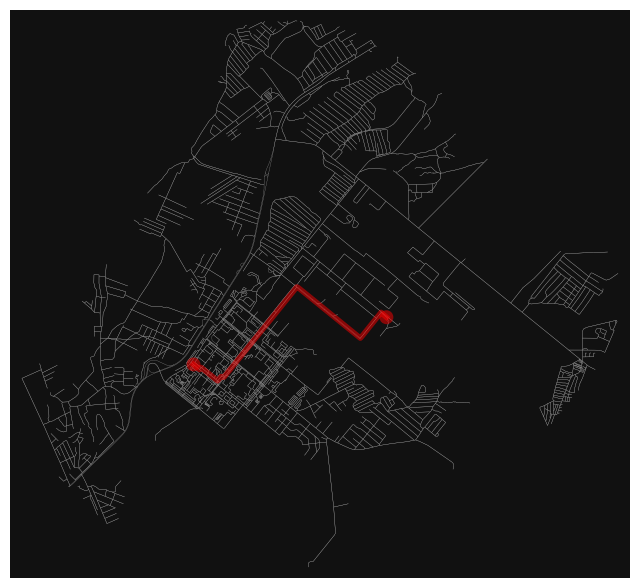

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [111]:
# Получение id узлов, ближайших к координатам
start = ox.distance.nearest_nodes(GR, 93.37633, 56.12736, return_dist=False)
finish = ox.distance.nearest_nodes(GR, 93.32469, 56.11990, return_dist=False)

# Расчет маршрута
route_GR = ox.routing.shortest_path(GR, start, finish)
print(len(route_GR))
ox.plot_graph_route(GR, route_GR, node_size=0, edge_linewidth=0.2)

Сравниваем длину полученных путей

In [112]:
route_G_length = ox.routing.route_to_gdf(G, route_G)['length'].sum()
route_GR_length = ox.routing.route_to_gdf(GR, route_GR)['length'].sum()
print(route_G_length, route_GR_length)

4567.209 4576.202871269884


In [125]:
1 - route_G_length/route_GR_length

0.0019653567647424097

То же самое для упрощенных графов

In [113]:
GS = ox.simplify_graph(G, edge_attrs_differ=['highway'])
print(GS.number_of_nodes(), GS.number_of_edges())

GRS = ox.simplify_graph(GR, edge_attrs_differ=['highway'])
print(GRS.number_of_nodes(), GRS.number_of_edges())

1968 5315
1965 5315


42


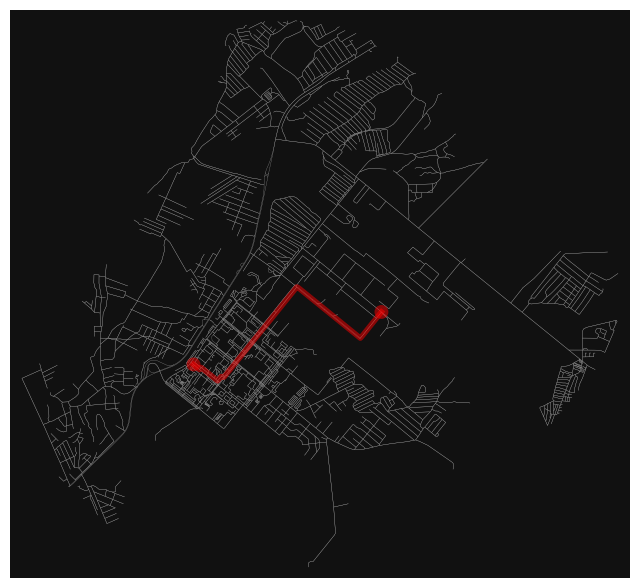

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [114]:
# Получение id узлов, ближайших к координатам
start = ox.distance.nearest_nodes(GS, 93.37633, 56.12736, return_dist=False)
finish = ox.distance.nearest_nodes(GS, 93.32469, 56.11990, return_dist=False)

# Расчет маршрута
route_GS = ox.routing.shortest_path(GS, start, finish)
print(len(route_GS))
ox.plot_graph_route(GS, route_GS, node_size=0, edge_linewidth=0.2)

42


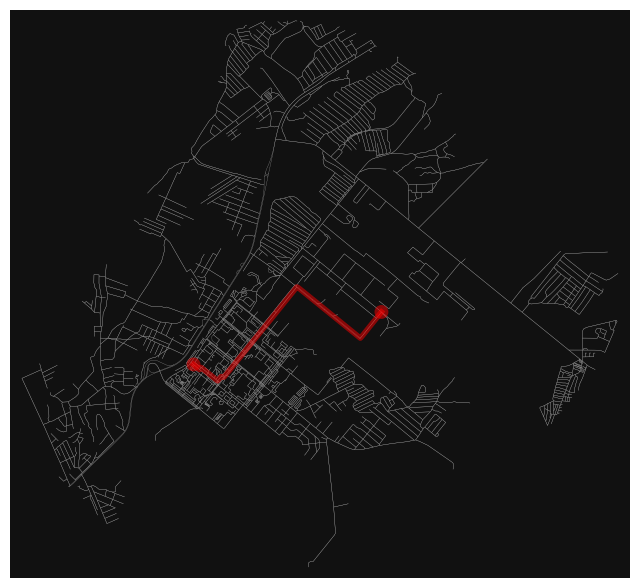

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [115]:
# Получение id узлов, ближайших к координатам
start = ox.distance.nearest_nodes(GRS, 93.37633, 56.12736, return_dist=False)
finish = ox.distance.nearest_nodes(GRS, 93.32469, 56.11990, return_dist=False)

# Расчет маршрута
route_GRS = ox.routing.shortest_path(GRS, start, finish)
print(len(route_GRS))
ox.plot_graph_route(GRS, route_GRS, node_size=0, edge_linewidth=0.2)

In [116]:
route_GS_length = ox.routing.route_to_gdf(GS, route_GS)['length'].sum()
route_GRS_length = ox.routing.route_to_gdf(GRS, route_GRS)['length'].sum()
print(route_GS_length, route_GRS_length)

4457.063 4465.826290177141


In [124]:
1 - route_GS_length/route_GRS_length

0.0019622998315936835

<span style='color:red'>Разница в длине пути между исходным и восставновленным графом значительно меньше чем между исходным и упрощенным графами!</span>

Менее 1%

In [117]:
ox.routing.route_to_gdf(GS, route_GS)

,,,osmid,lanes,name,highway,maxspeed,oneway,reversed,length,travel_time,geometry
u,v,key,,,,,,,,,,
2034401236,4116038783,0,32141404,NaN,NaN,service,NaN,False,False,8.111,0.016222,"LINESTRING (93.37440 56.12766, 93.37432 56.12761)"
4116038783,4116025705,0,32141404,NaN,NaN,service,NaN,False,False,124.187,0.248374,"LINESTRING (93.37432 56.12761, 93.37307 56.12674)"
4116025705,2034401233,0,32141404,NaN,NaN,service,NaN,False,False,368.103,0.736206,"LINESTRING (93.37307 56.12674, 93.36935 56.12415)"
2034401233,2468412831,0,239025487,NaN,NaN,unclassified,NaN,False,False,51.863,0.103726,"LINESTRING (93.36935 56.12415, 93.36880 56.12380)"
2468412831,4116025598,0,239025486,NaN,NaN,unclassified,NaN,True,False,573.154,1.146308,"LINESTRING (93.36880 56.12380, 93.36163 56.12705)"
4116025598,2468412834,0,239025486,NaN,NaN,unclassified,NaN,True,False,180.901,0.361802,"LINESTRING (93.36163 56.12705, 93.35936 56.12808)"
2468412834,4116020522,0,239025486,NaN,NaN,unclassified,NaN,True,False,150.176,0.300352,"LINESTRING (93.35936 56.12808, 93.35748 56.12893)"
4116020522,2468412837,0,239025486,NaN,NaN,unclassified,NaN,True,False,6.155,0.012310,"LINESTRING (93.35748 56.12893, 93.35740 56.12896)"
2468412837,2468412832,0,239025486,NaN,NaN,unclassified,NaN,True,False,94.545,0.189090,"LINESTRING (93.35740 56.12896, 93.35622 56.12950)"


In [118]:
ox.routing.route_to_gdf(GRS, route_GRS)

,,,name,highway,oneway,lanes,reversed,length,geometry
u,v,key,,,,,,,
1643,1640,0,NaN,service,False,NaN,False,8.125649,"LINESTRING (93.37440 56.12766, 93.37432 56.12761)"
1640,121,0,NaN,service,False,NaN,False,124.406089,"LINESTRING (93.37432 56.12761, 93.37307 56.12674)"
121,119,0,NaN,service,False,NaN,False,368.753838,"LINESTRING (93.37307 56.12674, 93.36935 56.12415)"
119,118,0,NaN,unclassified,False,NaN,False,51.958424,"LINESTRING (93.36935 56.12415, 93.36880 56.12380)"
118,120,0,NaN,unclassified,True,NaN,False,574.420292,"LINESTRING (93.36880 56.12380, 93.36163 56.12705)"
120,122,0,NaN,unclassified,True,NaN,False,181.300995,"LINESTRING (93.36163 56.12705, 93.35936 56.12808)"
122,3948,0,NaN,unclassified,True,NaN,False,150.507727,"LINESTRING (93.35936 56.12808, 93.35748 56.12893)"
3948,144,0,NaN,unclassified,True,NaN,False,6.169043,"LINESTRING (93.35748 56.12893, 93.35740 56.12896)"
144,140,0,NaN,unclassified,True,NaN,False,94.753720,"LINESTRING (93.35740 56.12896, 93.35622 56.12950)"


# Восстановление по геометрии упрощенного графа

In [119]:
roads = ox.graph_to_gdfs(GS, nodes=False)

GSR = graph_rise_from_gpkg(roads)
GSRS = ox.simplify_graph(GSR, edge_attrs_differ=['highway']) # Нельзя упростить граф который ранее уже был упрощен, но это нужно обработать


print('Исходный граф:')
print(G.number_of_nodes(), G.number_of_edges())

print('Исходный граф упрощенный и после этого восстановленный:')
print(GSR.number_of_nodes(), GSR.number_of_edges())

print('Исходный граф упрощенный:')
print(GS.number_of_nodes(), GS.number_of_edges())

print('Исходный граф восстановленный и после этого упрощенный:')
print(GRS.number_of_nodes(), GRS.number_of_edges())

print('Исходный граф граф упрощенный, восстановленный и после этого упрощенный:')
print(GSRS.number_of_nodes(), GSRS.number_of_edges())

Исходный граф:
5514 12199
Исходный граф упрощенный и после этого восстановленный:
5511 12199
Исходный граф упрощенный:
1968 5315
Исходный граф восстановленный и после этого упрощенный:
1965 5315
Исходный граф граф упрощенный, восстановленный и после этого упрощенный:
1965 5315


In [120]:
GS2 = ox.simplify_graph(G, edge_attrs_differ=['highway'])
print(GS2.number_of_nodes(), GS2.number_of_edges())

1968 5315


In [121]:
roads = ox.graph_to_gdfs(GSR, nodes=False)
roads['highway'].unique()

array(['secondary', 'service', 'tertiary', 'residential', 'unclassified',
       'track', 'footway', 'path', 'road', 'steps', 'secondary_link'],
      dtype=object)

In [122]:
roads.sample(20)

,,,highway,oneway,lanes,reversed,length,name,geometry
u,v,key,,,,,,,
2642,2643,0,service,False,NaN,True,31.362086,NaN,"LINESTRING (93.42268 56.11963, 93.42318 56.11965)"
4214,4215,0,service,False,NaN,False,7.313842,NaN,"LINESTRING (93.32380 56.12491, 93.32391 56.12489)"
2305,2304,0,service,False,NaN,False,23.277964,NaN,"LINESTRING (93.34373 56.16651, 93.34345 56.16637)"
4544,4477,0,service,False,NaN,True,56.845707,NaN,"LINESTRING (93.32361 56.13147, 93.32438 56.13174)"
855,853,0,service,False,NaN,True,78.408490,NaN,"LINESTRING (93.34506 56.12461, 93.34425 56.12407)"
2112,2097,0,unclassified,False,NaN,False,63.268437,NaN,"LINESTRING (93.37685 56.16085, 93.37603 56.16051)"
4819,4820,0,service,False,NaN,False,146.100286,NaN,"LINESTRING (93.35269 56.11521, 93.35437 56.11612)"
4380,4379,0,service,False,NaN,False,126.063302,NaN,"LINESTRING (93.33671 56.14510, 93.33480 56.14548)"
4809,4278,0,service,False,NaN,True,147.338939,NaN,"LINESTRING (93.35216 56.11550, 93.35386 56.11642)"
